<a href="https://colab.research.google.com/github/riturajs19/Braille-Image/blob/main/Braille_Image.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd
from shutil import copyfile

In [2]:
import os
os.environ['KAGGLE_USERNAME'] = 'rituraj19'
os.environ['KAGGLE_API_TOKEN'] = 'KGAT_5c9e4ea72a6bebc2fcf24dc930f23371'

In [3]:
!pip install -q kaggle --upgrade

In [4]:
!kaggle datasets list -s braille

ref                                                             title                                                     size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------------------  --------------------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
shanks0465/braille-character-dataset                            Braille Character Dataset                              1361006  2019-12-21 13:42:10.380000           4224         64  0.9375           
mdismielhossenabir/braille-character-image-classification       Braille Character Image Classification                 1013589  2025-05-13 01:50:46.780000            140          6  0.8125           
adviksharma/braille-images-for-english-characters               Braille Images for English Characters                    78125  2021-05-18 16:13:32                   374          9  0.75             


In [5]:
!kaggle datasets download -d shanks0465/braille-character-dataset

Dataset URL: https://www.kaggle.com/datasets/shanks0465/braille-character-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 1.30M/1.30M [00:00<00:00, 178MB/s]



In [6]:
!unzip braille-character-dataset.zip

Archive:  braille-character-dataset.zip
  inflating: Braille Dataset/Braille Dataset/a1.JPG0dim.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG0rot.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG0whs.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG10dim.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG10rot.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG10whs.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG11dim.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG11rot.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG11whs.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG12dim.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG12rot.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG12whs.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG13dim.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG13rot.jpg  
  inflating: Braille Dataset/Braille Dataset/a1.JPG13whs.jpg  
  inflating: Brail

In [7]:
import os
os.listdir()

['.config',
 'Dataset Description.txt',
 'braille-character-dataset.zip',
 'Braille Dataset',
 'sample_data']

In [9]:
os.listdir("Braille Dataset/Braille Dataset")

['b1.JPG19dim.jpg',
 'o1.JPG12whs.jpg',
 'e1.JPG14rot.jpg',
 'h1.JPG17dim.jpg',
 'f1.JPG9whs.jpg',
 'l1.JPG16whs.jpg',
 'i1.JPG17dim.jpg',
 'n1.JPG9whs.jpg',
 'e1.JPG2rot.jpg',
 't1.JPG3rot.jpg',
 'u1.JPG1rot.jpg',
 'k1.JPG3rot.jpg',
 'c1.JPG14dim.jpg',
 'a1.JPG8dim.jpg',
 'i1.JPG2rot.jpg',
 'a1.JPG18dim.jpg',
 'b1.JPG9rot.jpg',
 'p1.JPG2rot.jpg',
 'w1.JPG14rot.jpg',
 'v1.JPG3rot.jpg',
 'k1.JPG10whs.jpg',
 'j1.JPG4dim.jpg',
 't1.JPG19dim.jpg',
 'f1.JPG11dim.jpg',
 'n1.JPG5whs.jpg',
 'f1.JPG11rot.jpg',
 'p1.JPG3dim.jpg',
 'o1.JPG7rot.jpg',
 's1.JPG12rot.jpg',
 'b1.JPG1rot.jpg',
 'm1.JPG14whs.jpg',
 's1.JPG13whs.jpg',
 'e1.JPG13rot.jpg',
 's1.JPG1dim.jpg',
 'v1.JPG13whs.jpg',
 'r1.JPG14rot.jpg',
 'j1.JPG12rot.jpg',
 'a1.JPG4rot.jpg',
 'z1.JPG6whs.jpg',
 'v1.JPG3whs.jpg',
 'm1.JPG8whs.jpg',
 'e1.JPG1dim.jpg',
 'a1.JPG2dim.jpg',
 'v1.JPG16dim.jpg',
 'w1.JPG13dim.jpg',
 'b1.JPG6dim.jpg',
 'm1.JPG5rot.jpg',
 'y1.JPG8rot.jpg',
 'g1.JPG2rot.jpg',
 'w1.JPG16whs.jpg',
 'l1.JPG10rot.jpg',
 'r1.JP

In [10]:
import cv2
import numpy as np
import os

data = []
labels = []

path = "Braille Dataset/Braille Dataset"

for img_name in os.listdir(path):

    img_path = os.path.join(path, img_name)

    # Extract label (first character)
    label = img_name[0].upper()

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (28,28))

    data.append(img)
    labels.append(label)

data = np.array(data)
labels = np.array(labels)

print("Data shape:", data.shape)
print("Labels shape:", labels.shape)

Data shape: (1560, 28, 28)
Labels shape: (1560,)


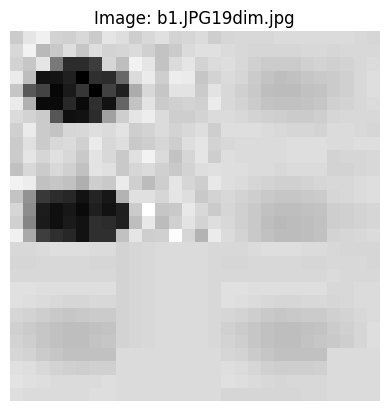

In [12]:
import matplotlib.pyplot as plt

img_name = os.listdir(path)[0]
img_path = os.path.join(path, img_name)

img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

plt.imshow(img, cmap='gray')
plt.title(f"Image: {img_name}")
plt.axis('off')
plt.show()

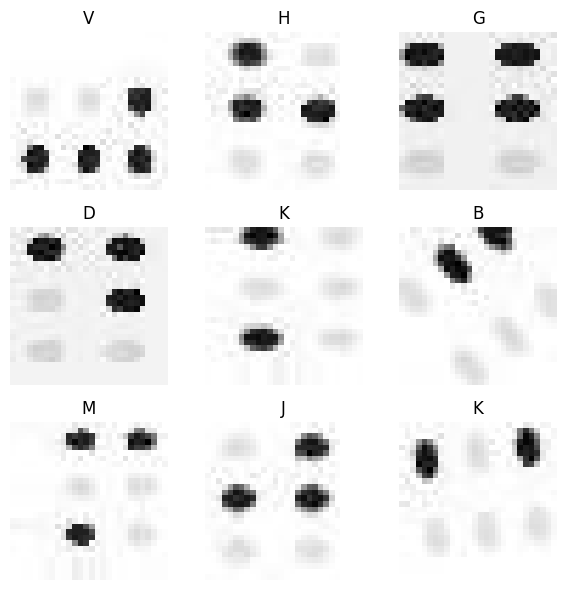

In [13]:
import random

images = os.listdir(path)
sample = random.sample(images, 9)

plt.figure(figsize=(6,6))

for i, img_name in enumerate(sample):
    img_path = os.path.join(path, img_name)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    plt.subplot(3,3,i+1)
    plt.imshow(img, cmap='gray')

    label = img_name[0].upper()
    plt.title(label)
    plt.axis('off')

plt.tight_layout()
plt.show()

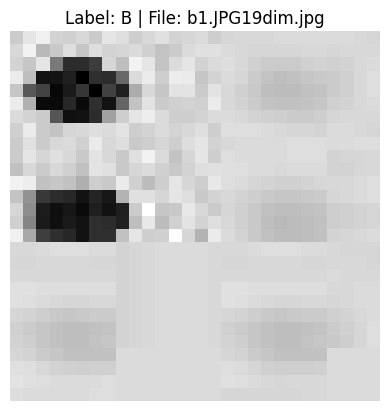

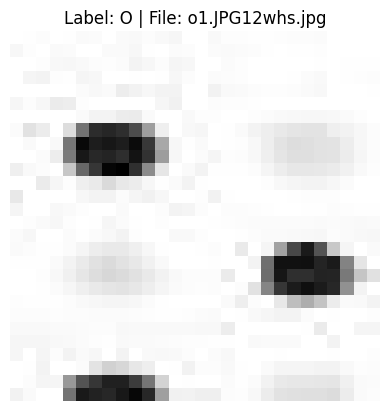

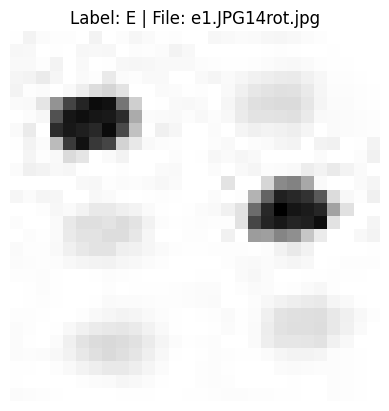

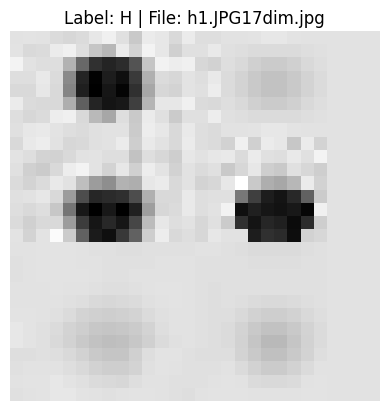

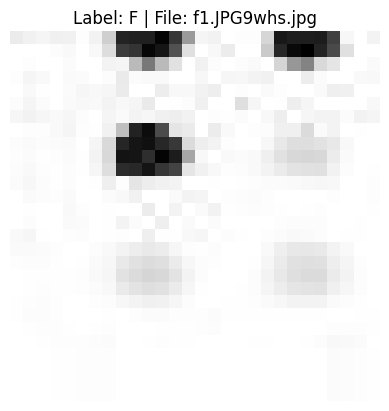

In [14]:
for i in range(5):
    img_name = images[i]
    img_path = os.path.join(path, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    label = img_name[0].upper()

    plt.imshow(img, cmap='gray')
    plt.title(f"Label: {label} | File: {img_name}")
    plt.axis('off')
    plt.show()

In [15]:
print(img.shape)

(28, 28)


In [16]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print(labels[:5])         # Original
print(labels_encoded[:5]) # Encoded

['B' 'O' 'E' 'H' 'F']
[ 1 14  4  7  5]


In [17]:
# Normalize (0–255 → 0–1)
data = data / 255.0

# Add channel dimension
data = data.reshape(-1, 28, 28, 1)

print(data.shape)

(1560, 28, 28, 1)


In [18]:
from sklearn.model_selection import train_test_split

# 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    data, labels_encoded, test_size=0.3, random_state=42
)

# split temp → val + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (1092, 28, 28, 1)
Val: (234, 28, 28, 1)
Test: (234, 28, 28, 1)


In [53]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential()

# 1️⃣ Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(2,2))

# 2️⃣ Deeper features
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D(2,2))

# 3️⃣ Flatten
model.add(Flatten())

# 4️⃣ Fully connected layer
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.4))

# 5️⃣ Output layer (26 classes)
model.add(Dense(26, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [55]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [56]:
model.evaluate(X_test, y_test)

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step - accuracy: 0.0385 - loss: 3.2561


[3.256101131439209, 0.03846153989434242]

In [57]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 4s 49ms/step - accuracy: 0.0495 - loss: 3.2612 - val_accuracy: 0.0983 - val_loss: 3.2272
Epoch 2/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.1236 - loss: 3.0979 - val_accuracy: 0.2906 - val_loss: 2.7795
Epoch 3/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3141 - loss: 2.4047 - val_accuracy: 0.5171 - val_loss: 1.9447
Epoch 4/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4615 - loss: 1.8828 - val_accuracy: 0.5726 - val_loss: 1.6585
Epoch 5/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5549 - loss: 1.5435 - val_accuracy: 0.6111 - val_loss: 1.4480
Epoch 6/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6016 - loss: 1.3452 - val_accuracy: 0.6239 - val_loss: 1.3514
Epoch 7/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6548 - loss: 1.1924 - val_accuracy: 0.6154 - val_loss: 1.3166
Epoch 8/20
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6758 - loss: 1.0609 - val_accuracy: 0.6325 - val_loss

8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step


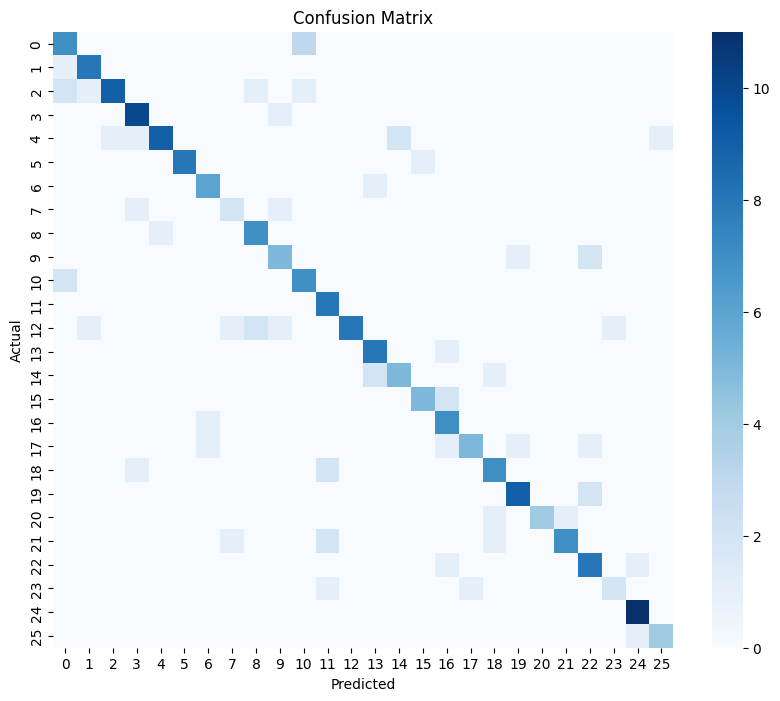

In [58]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=False, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [59]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.58      0.70      0.64        10
           1       0.80      0.89      0.84         9
           2       0.90      0.64      0.75        14
           3       0.77      0.91      0.83        11
           4       0.90      0.64      0.75        14
           5       1.00      0.89      0.94         9
           6       0.75      0.86      0.80         7
           7       0.50      0.50      0.50         4
           8       0.70      0.88      0.78         8
           9       0.62      0.62      0.62         8
          10       0.64      0.78      0.70         9
          11       0.62      1.00      0.76         8
          12       1.00      0.57      0.73        14
          13       0.73      0.89      0.80         9
          14       0.71      0.62      0.67         8
          15       0.83      0.71      0.77         7
          16       0.58      0.88      0.70         8
          17       0.83    

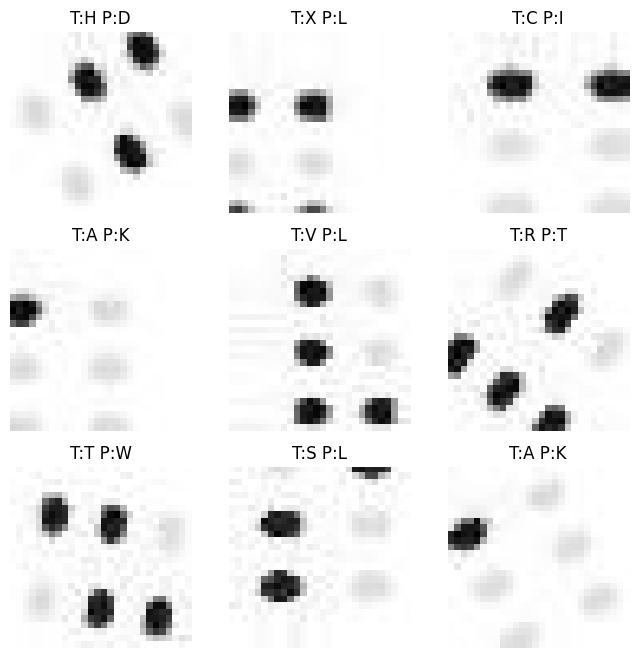

In [63]:
wrong = np.where(y_pred != y_test)[0]

plt.figure(figsize=(8,8))

for i, idx in enumerate(wrong[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')

    true_label = le.inverse_transform([y_test[idx]])[0]
    pred_label = le.inverse_transform([y_pred[idx]])[0]

    plt.title(f"T:{true_label} P:{pred_label}")
    plt.axis('off')

plt.show()

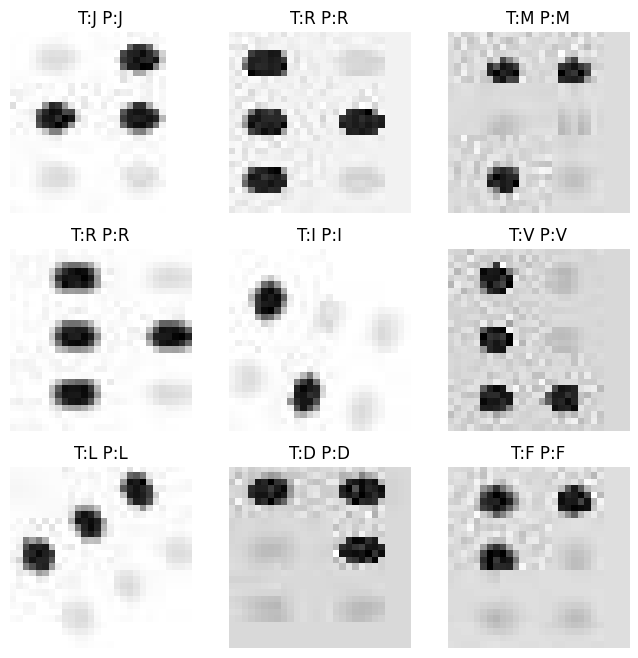

In [67]:
right = np.where(y_pred == y_test)[0]

plt.figure(figsize=(8,8))

for i, idx in enumerate(right[:9]):
    plt.subplot(3,3,i+1)
    plt.imshow(X_test[idx].reshape(28,28), cmap='gray')


    true_label = le.inverse_transform([y_test[idx]])[0]
    pred_label = le.inverse_transform([y_pred[idx]])[0]

    plt.title(f"T:{true_label} P:{pred_label}")
    plt.axis('off')

plt.show()

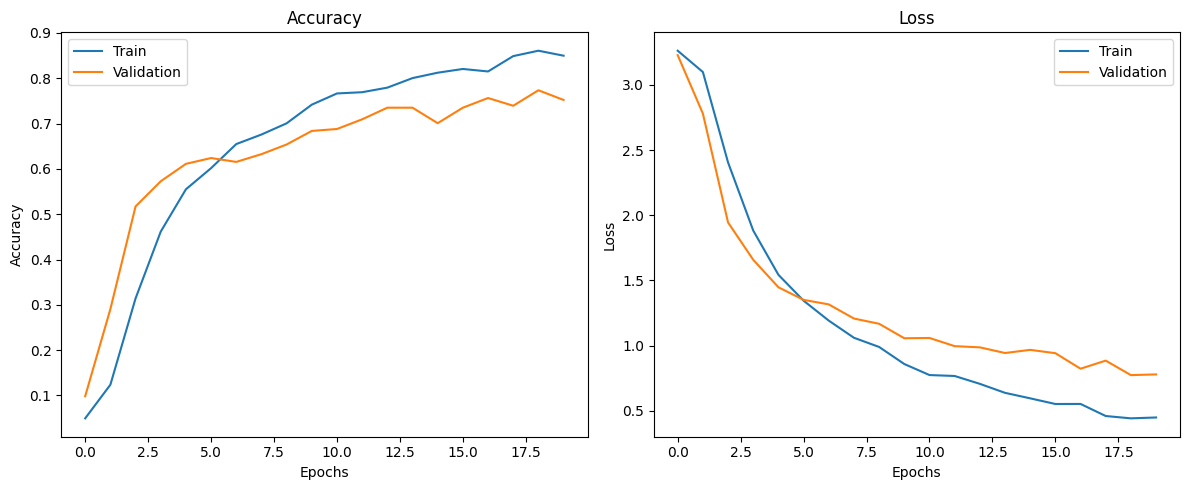

In [68]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [62]:
model.save("braille_model_final.h5")

import pickle
with open("label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)